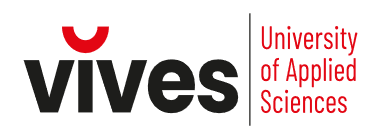<br>


**MACHINE LEARNING FUNDAMENTALS**<br>
APPLIED COMPUTER SCIENCE<br>
Specialization in Artificial Intelligence<br>
Andy Louwyck

---



---



# **SIMPLE LINEAR REGRESSION: INTRODUCTION**

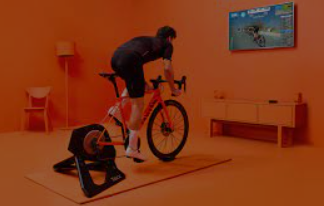

## CHALLENGE

Import the file "zwift_single.csv" as Pandas `DataFrame`. The file contains times and corresponding distances that were measured during a virtual bike ride on [Zwift](https://www.zwift.com/).

Print out the data frame and also provide the most important statistics. Make a scatter plot of the data, in which you plot the distance against time. So on the x-axis is the time, on the y-axis the distance.

Finally, try to **predict how many kilometers** the cyclist will have covered **after 2 hours of cycling** if he continues cycling at the same pace.

## SOLUTION

First we execute all necessary import statements:

In [234]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Exploring the dataset

We read that data in as a Pandas `DataFrame`:

In [235]:
zwift = pd.read_csv("zwift_single.csv", sep=";") # watch out! separator is semicolon!
zwift

,time (min),distance (km)
0,0,0.00
1,1,0.14
2,2,1.01
3,3,1.32
4,4,1.55
...,...,...
56,56,22.62
57,57,23.09
58,58,23.60
59,59,25.42


With the method `describe` we can retrieve the statistics:

In [236]:
zwift.describe().T  # T = transpose

,count,mean,std,min,25%,50%,75%,max
time (min),61.0,30.000000,17.752934,0.0,15.00,30.00,45.00,60.00
distance (km),61.0,12.553607,7.450547,0.0,6.09,12.19,18.92,25.49


We plot the data in a scatterplot:

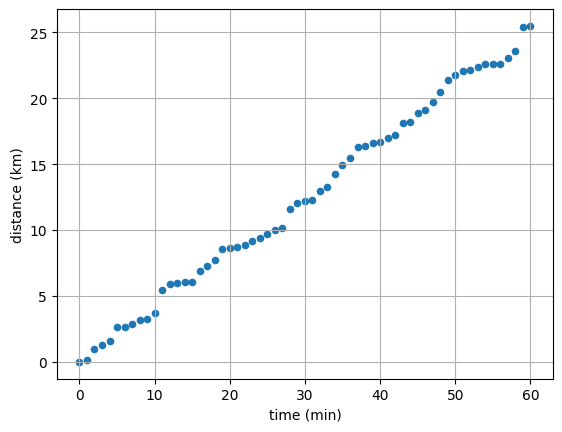

In [237]:
xlabel, ylabel = tuple(zwift.columns)
zwift.plot.scatter(x=xlabel, y=ylabel, grid=True);

### Prediction based on average speed

The easiest way to predict the distance after 2 hours of cycling is based on the average speed. In the statistics we see that the total time the cyclist has exercised is 60 minutes or 1 hour and that in that hour 25.49 km has been covered. The average speed is therefore 25.49 km/h. After 2 hours the cyclist will have covered the distance of 25.49 km twice, if he maintains this average speed.

In [238]:
d_max = zwift[ylabel].max()
print(f"The cyclist covered {d_max} km after 1 hour")
print(f"The cyclist will have covered {2 * d_max} km after 2 hours.")

The cyclist covered 25.49 km after 1 hour
The cyclist will have covered 50.98 km after 2 hours.


Speed ​​is defined as distance divided by time. If we give speed the symbol $v$, distance the symbol $d$ and time the symbol $t$, then the formula to calculate speed is:

> $v = \frac{d}{t}$

Time $t$ is the independent variable and is on the x-axis. Distance $d$ is the dependent variable and is on the y-axis. Rearranging the formula gives:

> $d = vt$

This is an equation of the form $y=ax$ (with $y=d$, $x=t$ and $a=v$), which represents a straight line through the origin. Parameter $a$ is the slope. In our example, we can set this slope equal to the average speed.

Since we want to estimate the distance, we take the given times and multiply them by the average speed. If we add those estimated distances to the scatterplot, we see that we effectively get a good fit.

In [239]:
# estimate distances
t = zwift[xlabel].values  # times in min
v = d_max / 60            # convert average speed to km/min
d = v * t                 # estimated distances in km

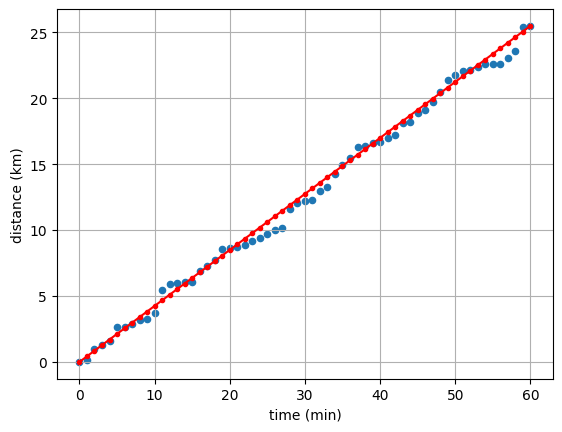

In [240]:
# scatterplot + line with estimated distances (red)
ax = zwift.plot.scatter(x=xlabel, y=ylabel, grid=True);
ax.plot(t, d, 'r.-');

It is interesting to now calculate and plot the differences between real and estimated distances.

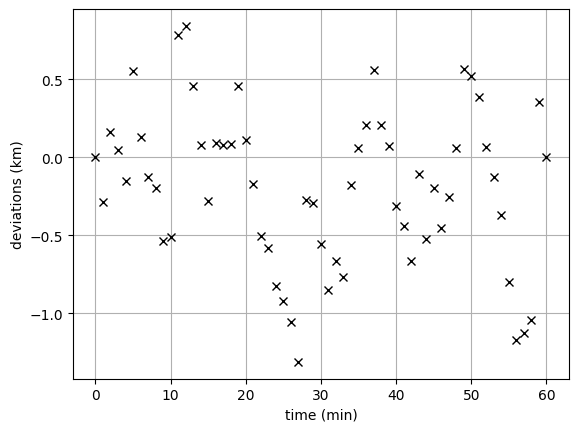

In [241]:
d_real = zwift[ylabel].values
differences = d_real - d
plt.plot(t, differences, 'kx');
plt.xlabel(xlabel);
plt.ylabel("deviations (km)");
plt.grid();

These differences are called deviations or **residuals**. We observe that there are more negative than positive deviations, which is confirmed by the negative sum:

In [242]:
print(np.sum(differences))

-11.674999999999901


To get a rough idea of how well the line fits the data points, we take the average of those deviations. **Caution!** Since positive and negative differences cancel each other out, we take the absolute value of the deviations!

In [243]:
mae = np.abs(differences).mean()
print(mae)

0.41887978142076465


This evaluation metric is called the **mean absolute error** (MAE).

### Brute force approach

Can we estimate the distances even better? Or in other words, can we find a straight line that is on average even closer to the data points? Let's investigate that.

We do this first by means of "brute force" or "exhaustive search". We go through a range of speeds, e.g. from 10 to 40, and we calculate the average deviation each time. This method is also called **grid search**, where the grid is 1D in this case, as we only have to optimize one parameter.

The code below does this graphically. The left graph is the scatter plot with the red line based on the average speed, and in black we add the straight line calculated with the new speed each time. The right graph plots the average deviation or error as a function of the speed. The red point in that graph is the average deviation that we calculated earlier for the straight line derived based on the average speed.

In [244]:
from matplotlib.animation import FuncAnimation
from matplotlib import rc
rc('animation', html='jshtml')

# average speed and range of speeds
v_avg = d_max # average speed
v_range = np.arange(10, 41) # range of speeds

# initialize figure and coordinate systems
fig, (ax1, ax2) = plt.subplots(1, 2) # create figure with 2 graphs
ax1.set_xlabel(xlabel)
ax1.set_ylabel(ylabel)
ax1.set_xlim((-5, 65))
ax1.set_ylim((-5, 45))
ax2.set_xlabel("speed (km/h)")
ax2.yaxis.set_label_position("right")
ax2.yaxis.tick_right()
ax2.set_ylabel("mean error (km)")
ax2.set_xlim((9, 41))
ax2.set_ylim((0, 8))

# the initialization function for the animation
def init():
    zwift.plot.scatter(x=xlabel, y=ylabel, ax=ax1) # scatterplot with the data points
    ax1.plot(t, t * v_avg / 60, 'r-') # red line based on average speed
    ax1.grid()
    ax2.plot([v_avg], [mae], 'ro') # red point with error of average speed
    ax2.grid()

# the update function for the animation
def update(v):
    d = t * v / 60 # estimate new distance
    error = np.abs(d - d_real).mean() # calculate the error
    ax1.plot(t, d, color='gray', linestyle='-', alpha=0.5) # draw the new line
    ax2.scatter(v, error, color='gray') # plot the error

# create the animation
ani = FuncAnimation(fig, update, frames=v_range,
init_func=init, blit=False, repeat=True)
plt.close()
ani

What do we see? The average deviation reaches a minimum around the average speed, but the red point is not the real minimum. One of the points has an even smaller error. So we can effectively draw a "better" straight line that will allow us to make an even "better" estimate of the distance traveled after 2 hours of cycling. To find that "best fit" straight line we are going to use **linear regression**.

Note that for the live plot we use matplotlib's `FuncAnimation`, which allows us to develop an animation

### Linear regression

In this Machine Learning course we will very often use **Scikit-Learn**, a machine learning library for Python. In it a class is implemented for linear regression. We will use that to find the best fitting line.

In [245]:
from sklearn.linear_model import LinearRegression

m = LinearRegression(fit_intercept=False) # straight through the origin, so no intercept!
m.fit(zwift[[xlabel]], zwift[ylabel])

print(f"slope is {m.coef_[0]}")
v_best = m.coef_[0] * 60
print(f"corresponding speed is slope x 60 = {v_best:.2f} km/h")

slope is 0.4185359707356727
corresponding speed is slope x 60 = 25.11 km/h


The best speed to calculate the distance after 2 hours is therefore slightly lower than the average speed, i.e. 25.11 km/h. After 2 hours the cyclist will probably also have covered slightly fewer kilometers:

In [246]:
print(f"The cyclist will have covered {2 * v_best :.2f} km after 2 hours.")

The cyclist will have covered 50.22 km after 2 hours.


Of course, the mean absolute error is also smaller. In fact, it is the smallest possible average error for this dataset:

In [247]:
d = t * v_best / 60
print(np.abs(d_real - d).mean())

0.3940947048358544


When we calculate and plot the residuals, we observe that they are centered around zero now:

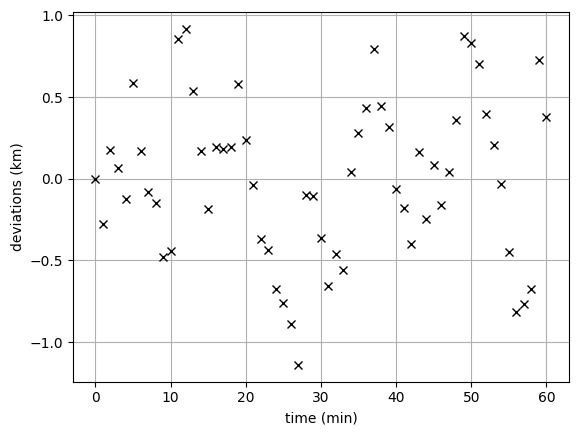

In [248]:
differences = d_real - d
plt.plot(t, differences, 'kx');
plt.xlabel(xlabel);
plt.ylabel("deviations (km)");
plt.grid();

Let's plot the best-fitting straigth line:

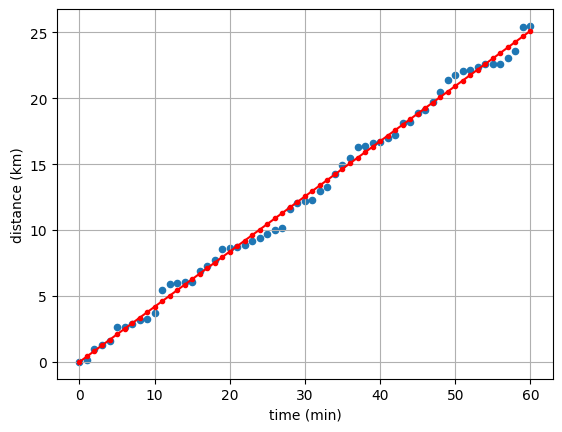

In [249]:
ax = zwift.plot.scatter(x=xlabel, y=ylabel, grid=True);
ax.plot(t, d, 'r.-');

But how do we find this best-fitting line? By minimizing the sum of the squares of the differences between the observed and the predicted distances. This is called the **[ordinary least squares](https://en.wikipedia.org/wiki/Ordinary_least_squares)** (OLS) method. Below, we explain the mathematical derivation in detail for the interested reader.

The line has the following equation:

> $\hat{d}_i = vt_i$  with $i=0,1,2,...,n$

where $\hat{d}_i$ is the predicted distance for time $t_i$. Subscript $i$ refers to the $i$-th sample or data point in the dataset. In total, there are $n$ samples.

The real distance $d_i$, which is the distance observed at time $t_i$, is:

> $d_i = vt_i + \epsilon_i$

with $\epsilon_i$ the **deviation** equal to:

> $\epsilon_i = d_i - \hat{d}_i$

Note that $\epsilon$ is also called **error** or **residual**.

Instead of minimizing the mean absolute error, we'll use the **sum of squared errors** (SSE) as it is mathematically more convenient to differentiate this function:

> $L = \sum_{i=1}^n\epsilon_i^2$

In general, $L$ is called the error or **loss function**.

The minimum of $L$ corresponds to the point in which the tangent line is horizontal, which implies its slope is zero. Mathematically, the derivate of $L$ with respect to $v$ is zero in that point or:

> $\dfrac{dL}{dv} = 0$

Solving the above equation will give us the optimal value for $v$, which is also the slope of the best-fitting line.

Let's do that by applying the *chain rule:*

> $\dfrac{dL}{dv} = \dfrac{d\big(\sum_{i=1}^n\epsilon_i^2\big)}{dv} = \sum_{i=1}^n\dfrac{d\epsilon_i^2}{dv} = \sum_{i=1}^n\big(2\epsilon_i \dfrac{d\epsilon_i}{dv} \big) = \sum_{i=1}^n\big[2(d_i - vt_i) (-t_i) \big]=2\sum_{i=1}^n\big(vt_i^2-d_it_i\big)=0$

Rearraning the above expression gives:

> $v\sum_{i=1}^nt_i^2 = \sum_{i=1}^nd_it_i$

Finally, we obtain an expression for $v$:

> $v = \dfrac{\sum_{i=1}^nd_it_i}{\sum_{i=1}^nt_i^2}$

When applying this formula, we get exactly the same value as the slope derived by the linear regression model:

In [250]:
t, d = tuple(zwift.columns)
print((zwift[t] * zwift[d]).sum() / (zwift[t] ** 2).sum())

0.4185359707356727


### Gradient Descent

The linear regression algorithm built into Scikit-Learn is based on the ordinary least squares method (OLS), which is only applicable to linear regression problems. Therefore, we are going to discuss the **[Gradient Descent](https://en.wikipedia.org/wiki/Gradient_descent)** algorithm in detail, because this algorithm is applied to many other machine learning problems. Just like our "brute-force" algorithm, Gradient Descent will also use the deviations between true and estimated values. Only, it will try to find the minimum in a more intelligent way by descending the slope of the loss function. Hence the name...

The algorithm starts with a random value for $v$. This value corresponds to a random point on the curve of loss function $L$, which is the sum of squared errors (SSE). The idea is to update this value iteratively until it is close enough to the minimum of loss function $L$. We do that by going downhill in the direction of that minimum. The steps that the algorithm takes towards the minimum are controlled by the derivate of the loss function, which determines the slope of the curve. So, when the derivative is large, the slope is steep, and the algorithm can take a large step. When it is approaching the minimum, the curve is less steep, and the steps become smaller.

Mathematically, the value for $v$ during iteration $k$ is updated using the value for $v$ from previous iteration $k-1$ and the derivative of the loss function $L$ with respect to $v$:

> $v_k = v_{k-1} - \dfrac{\alpha}{2} \dfrac{dL}{dv}$  with  $k=1,2,...,n_{iter}$

with hyperparameter $\alpha$ the **learning rate** which enables the user to control the step size. The total number of iterations is $n_{iter}$. Note that the derivative of $L/2$ is taken to cancel out the exponent after deriving $L$ with respect to $v$, which is fine as $\alpha$ is a constant set by the user.

Recall that the derivative is equal to:

> $\dfrac{dL}{dv} = -2\sum_{i=1}^n \epsilon_i t_i$

Combining the two equations gives the final expression to update $v$:

> $v_k = v_{k-1} + \alpha\sum_{i=1}^n \epsilon_i t_i$  with  $k=1,2,...,n_{iter}$

Usually, many iterations are needed to accurately approximate the minimum of the loss function.

The following function implements the Gradient Descent algorithm for solving the problem of fitting a straight line to our Zwift dataset:

In [251]:
def gradient_descent(t, d, niter, alpha, seed=None):
    """
    Gradient Descent algorithm for fitting a straight-line to the Zwift dataset

    Input parameters:
    - t: array with times, which is the independent variable (length is n)
    - d: array with distances, which is the dependent variable (length is n)
    - niter: integer that determines the number of iterations
    - alpha: float that determines the learning rate
    - seed: integer that determines the random seed (optional)

    Output parameters:

    Return values:
    - v: array with the slope derived after each iteration (length is niter)
    - L: array with SSE calculated after each epoch (length is niter)
    The optimal value ​for the slope is therefore v[-1],
    and the corresponding SSE is L[-1]
    """

    # initialize
    if seed: np.random.seed(seed)
    v = np.random.rand()  # assign random value between 0 and 1 to v
    v_path = [] # we are going to keep track of all values ​​of slope v
    L = [] # loss function

    # iterate
    for _ in range(niter):
        v += alpha * ((d - v * t) * t).sum()  # adjust speed (slope)
        v_path.append(v)                      # save current value of v
        L.append(np.sum((d - (v * t)) ** 2))  # loss function: SSE

    # output
    return np.array(v_path), np.array(L)

Let's apply the function using 100 epochs and a learning rate equal to $10^{-6}$:

In [252]:
v, L = gradient_descent(zwift[t].values, zwift[d].values, 100, 1e-6, seed=1234)

Plotting loss $L$ as a function of the number of epochs:

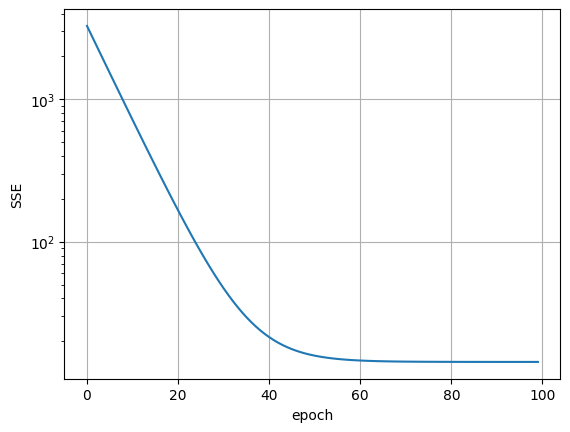

In [253]:
plt.semilogy(L);
plt.grid();
plt.xlabel("epoch");
plt.ylabel("SSE");

The optimal value for $v$ is the last value in array `v`:

In [254]:
print(v[-1])

0.4184297849886552


This corresponds to the following optimal speed for predicting the distance after two hours of cycling:

In [255]:
print(v[-1] * 60)

25.10578709931931


We see it is very close indeed to the optimal value calculated using the exact solution!

Finally, we make a plot of the steps the Gradient Descent algorithm takes to find the minimum:

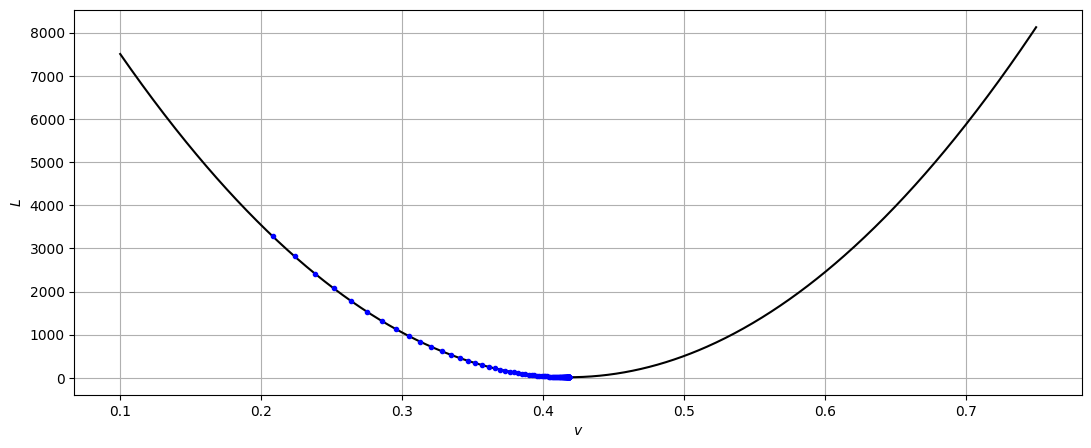

In [256]:
# calculate SSE for a range of v values to plot the L curve
v_range = np.linspace(0.1, 0.75, 1000)
SSE = []
for v_i in v_range:
    dp = v_i * zwift[t].values
    SSE.append(np.sum((zwift[d].values - dp)**2))

# plot of L curve (black line) and steps (blue dots)
plt.figure(figsize=(13, 5))
plt.plot(v_range, SSE, 'k-')
plt.plot(v, L, 'b.');
plt.xlabel("$v$");
plt.ylabel("$L$");
plt.grid();

### Our first neural net

We can also solve regression problems using artificial neural networks. In fact, the simple linear regression that we solved using Gradient Descent is the simplest neural network we can construct. In this notebook, we demonstrate this by fitting our Zwift dataset using [Keras](https://keras.io/), a Python interface for Deep Learning.

For linear regression we need **a neural network with only one neuron**. In Keras, we define a `Sequential` model with 1 `Dense` layer that contains 1 node or `unit`:

In [257]:
from tensorflow import keras
from keras import Sequential, layers

model = Sequential()                         # Sequential is a class that we must instantiate
model.add(layers.Dense(units=1,              # using method add() we add a Dense layer with 1 unit
                       activation='linear',  # using the default linear activation function
                       use_bias=False))      # disabling bias to set the intercept to zero

By default, the `activation` function is `'linear'`, which means the node applies a linear transformation to input $x$:

> $y = wx + b$

This is an equation that represents a straight line, where $w$ is the slope and $b$ is the intercept. In deep learning, it is common to call $w$ the **weight** and $b$ the **bias**. Because our model is a straight line through the origin, we know the intercept is zero, and that is why we set `use_bias` to `False`.

Weight $w$ is the **model parameter**, which the gradient descent algorithm modifies step-by-step in order to minimize the loss function.

In Keras, we use the **stochastic gradient descent** (SGD) optimizer, which is a variant of gradient descent that uses a single sample or a batch of samples to approximate the gradient instead of all samples.

Furthermore, we use the **mean squared error** (MSE) as loss function, which is the sum of squared errors (SSE) divided by the total number of samples.

Optimizer and loss function are defined when compiling the model:


In [258]:
sgd = keras.optimizers.SGD(learning_rate=1e-6)  # SGD is also a class that we have to instantiate
model.compile(optimizer=sgd, loss="MSE")        # MSE is the loss function to be minimized by SGD

Like before, we set the learning rate to `1e-6`.

It is common to assign the input variables to `X` and the target to `y`. In most cases, feature matrix `X` is two-dimensional as it contains more than one feature. Here, we only have one feature, which we need to reshape into a 2D matrix.

In [259]:
X = zwift[xlabel].values[:, np.newaxis]  # input X must be 2D
y = zwift[ylabel].values                 # target y

We define 50 epochs to train the model. During one **epoch**, the model processes all samples in random order. Here, we set the `batch_size` to 1, which means the gradient is approximated using one sample at a time. This is called **"true SGD"**. However, in case of large datasets, it is more convenient to use **batches**, in which case the model uses more than one sample to calculate the gradient. This is called **"mini-batch SGD"**. Recall that our `gradient_descent()` function uses all samples to calculate the exact value of the gradient. This is called **"full (batch) gradient descent"**.

Let's train the model by involing method `fit()`:

In [260]:
history = model.fit(X, y,                # input variable X and target y (supervised learning!)
                    batch_size=1,        # the model processes one sample at a time (true SGD)
                    epochs=50,           # the model processes all samples 50 times
                    verbose=0);          # no printing

It's useful to plot the evolution of the loss as a function of the number of epochs. Here, we clearly observe that the loss function reaches its minimum:

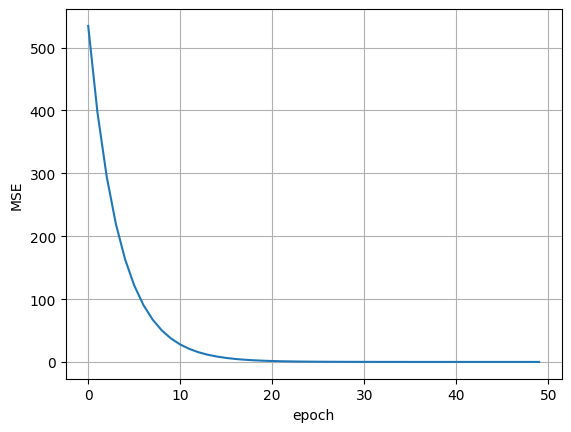

In [261]:
plt.plot(history.history['loss']);
plt.xlabel('epoch');
plt.ylabel('MSE');
plt.grid();

Let's get the final MSE by calling method `evaluate()`:

In [262]:
mse = model.evaluate(X, y, verbose=0)
print(mse)

0.23536744713783264


To calculate the optimal speed, we need the weight of the model. Because most neural nets contain many layers with many nodes, getting the weight is a bit cumbersome:

In [263]:
w = model.layers[0].weights[0].numpy().item()  # getting weight w
print(f"optimal speed is {w * 60} km/h")

optimal speed is 25.08518099784851 km/h


The solution found by the Keras model is also very close to the exact solution calculated using OLS!

---

# **MULTIPLE LINEAR REGRESSION: INTRODUCTION**

In the previous section, we explored **Simple Linear Regression**, where we predicted a dependent variable (distance) using only one independent variable (time). This approach works well when the relationship between two variables is linear.

However, in many real-world scenarios, the dependent variable might be influenced by multiple independent factors. **Multiple Linear Regression** generalizes simple linear regression by allowing for more than one independent variable to predict the dependent variable. This enables us to model more complex relationships and make more accurate predictions by considering various contributing factors simultaneously.

## CHALLENGE

Read the file "zwift_multiple.csv" into a Pandas `DataFrame`. The file contains times, slopes and corresponding distances of segments that were measured again during a virtual bike ride on Zwift.

Print out the data frame and also provide the most important statistics. Create a 3D scatter plot in which you plot distance against time and time multiplied by slope. The latter is called an **interaction variable** and it represents the combined effect of time and slope on the distance.

**Fit the data** using distance as the dependent variable, with time as an independent variable, and include the interaction term as an additional independent variable.

Finally, try to **predict how many kilometers** the cyclist will have covered **after 2 hours of cycling** when the **slope is 10 %**.

## SOLUTION

### Exploring the dataset

We read the data into a Pandas `DataFrame`:

In [264]:
zwift = pd.read_csv("zwift_multiple.csv", sep=";") # watch out! separator is semicolon!
zwift.head()

,time (min),slope,distance (km)
0,4,-0.00,2.249
1,13,0.07,5.206
2,11,-0.04,6.505
3,8,-0.01,3.906
4,8,0.12,2.639


Getting the summarizing statistics:

In [265]:
zwift.describe().T  # T = transpose

,count,mean,std,min,25%,50%,75%,max
time (min),50.0,9.54000,3.676789,3.000,7.0000,10.000,13.00000,15.000
slope,50.0,0.06400,0.066148,-0.050,0.0025,0.065,0.12000,0.190
distance (km),50.0,3.82906,1.935704,0.705,2.1605,3.878,5.20325,8.301


We define the interaction variable:

In [266]:
time, slope, distance = tuple(zwift.columns)
time_slope = "time_slope"
zwift[time_slope] = zwift[time] * zwift[slope]

We create an interactive 3D scatterplot using `plotly`:

In [267]:
import plotly.express as px

fig = px.scatter_3d(zwift, x=zwift[time], y=zwift[time_slope], z=zwift[distance],
                    labels={'x': 'time (min)', 'y': 'time x slope', 'z': 'distance (km)'},
                    title='Interactive 3D Scatter Plot of Zwift Data')

fig.update_layout(scene = dict(
                    xaxis_title='time (min)',
                    yaxis_title='time x slope',
                    zaxis_title='distance (km)'))

fig.show()

The data points seem to align in such a way that they form a two-dimensional plane in the surrounding 3D space...

### Linear regression using Scikit-Learn

We will apply the following linear model:

> $d = v_0 \cdot t + \Delta v \cdot (t \cdot s)$

where

- $d$ is the distance (km)
- $t$ is the time (min)
- $s$ is the slope (dimensionless)
- $v_0$ is the baseline speed on flat terrain (km/min)
- $\Delta v$ is the slope effect on the speed (km/min)

The dependent variable is distance $d$ and the independent variables are $t$ and $(t\cdot s)$. As already mentioned, the latter is called an interaction variable. The model parameters are $v_0$ and $\Delta v$.

In general, the equation has the form:

> $y = w_1 X_1 + w_2 X_2 + b$

This represents a plane in 3D space. If the intercept $b = 0$, the plane passes through the origin, which is the case here.

Let's use Scikit-Learn to fit this model to the data. First we design feature matrix `X` and target vector `y`. Both are converted to NumPy arrays:

In [268]:
# Design feature matrix X and target vector y
X = zwift[[time, time_slope]].values  # 2D numpy matrix
y = zwift[distance].values  # 1D numpy vector

We create a `LinearRegression` object and pass `X` and `y` to its `fit()` method. Note that we set `fit_intercept` to `False` because the intercept is zero:

In [269]:
# Fit model
model = LinearRegression(fit_intercept=False)  # plane through the origin!
model.fit(X, y)

LinearRegression(fit_intercept=False)

Let's calculate the model score **R²**, which is a number between 0 and 1:

In [270]:
model.score(X, y)  # returns R²

0.9623217998205145

The model scores very close to 1 which indicates a very strong linear relationship.

The coefficients correspond to $v_0$ and $\Delta v$:

In [271]:
# Get coefficients
v0, delta_v = model.coef_
print(f"v0 = {v0:.4f} km/min or {v0*60:.2f} km/h")
print(f"Δv = {delta_v:.4f} km/min or {delta_v*60:.2f} km/h per unit slope")

v0 = 0.4912 km/min or 29.47 km/h
Δv = -1.4793 km/min or -88.76 km/h per unit slope


Calculating the MSE:

In [272]:
y_pred = v0 * X[:, 0] + delta_v * X[:, 1]
print(np.square(y - y_pred).mean())

0.13835477668709154


We can also apply the **dot-product**:

In [273]:
y_pred = np.dot(X, model.coef_)
print(np.square(y - y_pred).mean())

0.13835477668709154


Or we can invoke the `predict()` method:

In [274]:
y_pred = model.predict(X)
print(np.square(y - y_pred).mean())

0.13835477668709154


Predicting the distance after two hours when the slope is 10%:

In [275]:
t = 2 * 60    # convert 2 hours to min
s = 10 / 100  # divide % by 100

d = v0*t + delta_v*t*s  # predicted distance using the formula
print(f"distance is {d:.2f}")

distance is 41.20


Using method `predict()`:

In [276]:
d = model.predict([[t, t*s]]).item()
print(f"distance is {d:.2f}")

distance is 41.20


Recall that Scikit-Learn uses the **ordinary least squares method** to find an exact solution. Of course, it is also possible to apply **gradient descent** to approximate this solution. This is discussed in more detail in the course material of this topic. As an exercise, try to train a Keras model to fit the dataset!

---